In [11]:
import os
import numpy as np
import matplotlib.pyplot

def folderpath(srcDir):
    pathscsv = []
    for dirpath, dirnames, filenames in os.walk(srcDir):
        for d in dirnames:
            if 'csv' in d:
                 pathscsv.append (str(os.path.join(dirpath, d)))
    
    pathscsv = list( dict.fromkeys(pathscsv) ) 
    
    return pathscsv

import tkinter as tk
from tkinter import filedialog
root = tk.Tk()
root.withdraw()
dirname = filedialog.askdirectory(parent=root,initialdir="/",title='Please select a directory')

csvpath = folderpath(dirname)
print(csvpath)

['C:/Users/nadia/Box/Nadia_WeaverLab/Data/Experiments/Y654F_mutant/Flag/250902_24H_FLAG\\TIFF\\3_Channel_3\\csv']


In [12]:
def datapoints_by_keyword(paths, keyword):
    """
    Finds all csv files in a list of directories that contain 
    the specific keyword provided.
    """
    matched_files = []
    for path in paths:
        for (dirpath, dirnames, filenames) in os.walk(path):
            # Find files that match the .csv, and the specific keyword
            names = [
                os.path.join(dirpath, name) for name in filenames 
                if '.csv' in name
                and keyword in name
            ]
            matched_files.extend(names)
            break # Assuming you only want the top level of each csvpath
            
    return matched_files

targets = ['IWP2', 'Wnt3a', 'CHIR', 'Parental', 'WT__', 'Y654F__']
# Searching all directories in 'csvpath' for each
experiments = {k: datapoints_by_keyword(csvpath, k) for k in targets}

# Clean up: Remove keys that didn't find any files (optional)
experiments = {k: v for k, v in experiments.items() if v}

print(experiments)

{'IWP2': ['C:/Users/nadia/Box/Nadia_WeaverLab/Data/Experiments/Y654F_mutant/Flag/250902_24H_FLAG\\TIFF\\3_Channel_3\\csv\\1-1-WT_++_IWP2_1_24h_647-Flag_DAPI_20x_Galvano_001_Ch3.csv', 'C:/Users/nadia/Box/Nadia_WeaverLab/Data/Experiments/Y654F_mutant/Flag/250902_24H_FLAG\\TIFF\\3_Channel_3\\csv\\1-1-WT_++_IWP2_1_24h_647-Flag_DAPI_20x_Galvano_002_Ch3.csv', 'C:/Users/nadia/Box/Nadia_WeaverLab/Data/Experiments/Y654F_mutant/Flag/250902_24H_FLAG\\TIFF\\3_Channel_3\\csv\\1-1-WT_++_IWP2_1_24h_647-Flag_DAPI_20x_Galvano_003_Ch3.csv', 'C:/Users/nadia/Box/Nadia_WeaverLab/Data/Experiments/Y654F_mutant/Flag/250902_24H_FLAG\\TIFF\\3_Channel_3\\csv\\1-1-WT_++_IWP2_2_24h_647-Flag_DAPI_20x_Galvano_001_Ch3.csv', 'C:/Users/nadia/Box/Nadia_WeaverLab/Data/Experiments/Y654F_mutant/Flag/250902_24H_FLAG\\TIFF\\3_Channel_3\\csv\\1-1-WT_++_IWP2_2_24h_647-Flag_DAPI_20x_Galvano_002_Ch3.csv', 'C:/Users/nadia/Box/Nadia_WeaverLab/Data/Experiments/Y654F_mutant/Flag/250902_24H_FLAG\\TIFF\\3_Channel_3\\csv\\1-1-WT_++_IWP

In [14]:
#Plotting the figure
from scipy import stats

import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import linregress

x_data = pd.DataFrame()
y_data = pd.DataFrame()
datatotal = pd.DataFrame(columns = ['slice', 'roi_index', 'mean channel 1', 'mean channel 2'])

for i, listoffiles in enumerate(experiments):
    print(listoffiles)
    data_perexp = pd.DataFrame(columns = ['slice', 'roi_index', 'mean channel 1', 'mean channel 2'])

    
    for file in experiments[listoffiles]:
        print(file)
        data = pd.read_csv(file)
        data_perexp = pd.concat([data_perexp, data], ignore_index=True)
        #print(datatotal)
       

    x = data_perexp['mean channel 1']
    #print(x.size)

    y = data_perexp['mean channel 2']
    #print(y.size)
    
    x_data.loc[:,"bCat_"+str(i+1)] = (x.subtract(x[x.idxmin()])).divide(x[x.idxmax()])
    #x_data.loc[:,"Trep_"+str(i+1)] = x.divide(x[x.idxmax()])
    #x_data.loc[:,"Trep_"+str(i+1)] = x
    y_data.loc[:,"Dox_"+str(i+1)] = (y.subtract(y[y.idxmin()])).divide(y[y.idxmax()])
    #y_data.loc[:,"Tab_"+str(i+1)] = y.divide(y[y.idxmax()])
    #y_data.loc[:,"Tab_"+str(i+1)] = y



IWP2
C:/Users/nadia/Box/Nadia_WeaverLab/Data/Experiments/Y654F_mutant/Flag/250902_24H_FLAG\TIFF\3_Channel_3\csv\1-1-WT_++_IWP2_1_24h_647-Flag_DAPI_20x_Galvano_001_Ch3.csv
C:/Users/nadia/Box/Nadia_WeaverLab/Data/Experiments/Y654F_mutant/Flag/250902_24H_FLAG\TIFF\3_Channel_3\csv\1-1-WT_++_IWP2_1_24h_647-Flag_DAPI_20x_Galvano_002_Ch3.csv
C:/Users/nadia/Box/Nadia_WeaverLab/Data/Experiments/Y654F_mutant/Flag/250902_24H_FLAG\TIFF\3_Channel_3\csv\1-1-WT_++_IWP2_1_24h_647-Flag_DAPI_20x_Galvano_003_Ch3.csv
C:/Users/nadia/Box/Nadia_WeaverLab/Data/Experiments/Y654F_mutant/Flag/250902_24H_FLAG\TIFF\3_Channel_3\csv\1-1-WT_++_IWP2_2_24h_647-Flag_DAPI_20x_Galvano_001_Ch3.csv
C:/Users/nadia/Box/Nadia_WeaverLab/Data/Experiments/Y654F_mutant/Flag/250902_24H_FLAG\TIFF\3_Channel_3\csv\1-1-WT_++_IWP2_2_24h_647-Flag_DAPI_20x_Galvano_002_Ch3.csv
C:/Users/nadia/Box/Nadia_WeaverLab/Data/Experiments/Y654F_mutant/Flag/250902_24H_FLAG\TIFF\3_Channel_3\csv\1-1-WT_++_IWP2_2_24h_647-Flag_DAPI_20x_Galvano_003_Ch3.csv

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


Processing group: IWP2


The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.
The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.
The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.
The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.
The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.
The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.
The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.
The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.
The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.
The PostScript back

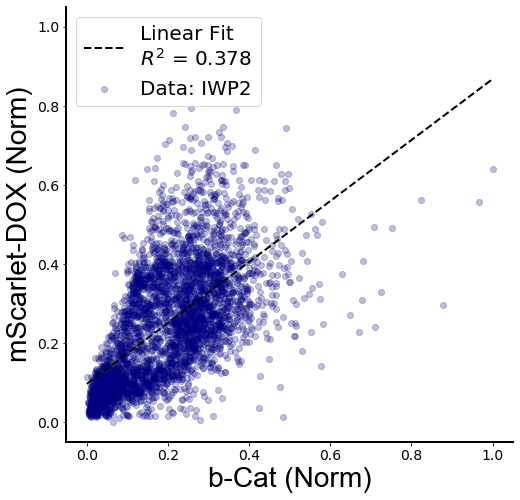

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.
The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


Processing group: Wnt3a


The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.
The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.
The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.
The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.
The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.
The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.
The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.
The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.
The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.
The PostScript back

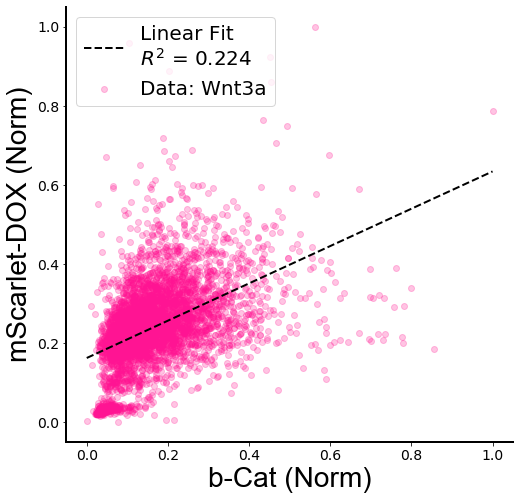

Processing group: CHIR


The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.
The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.
The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.
The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.
The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.
The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.
The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.
The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.
The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.
The PostScript back

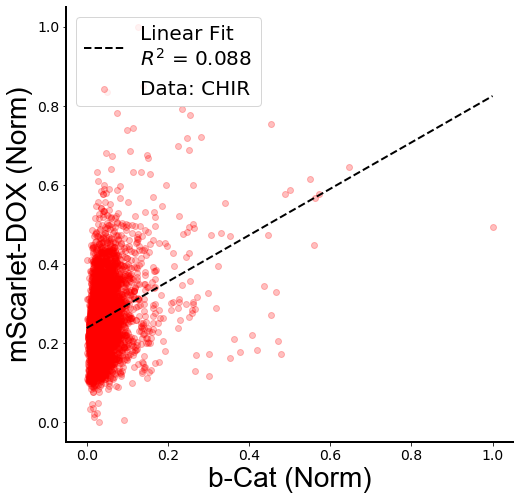

Processing group: Parental


The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.
The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.
The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.
The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.
The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.
The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.
The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.
The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.
The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.
The PostScript back

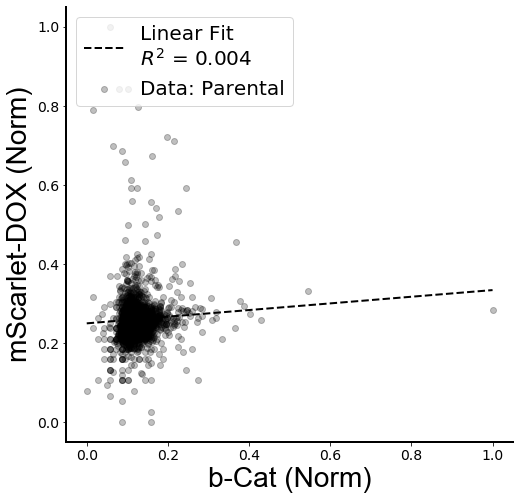

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


Processing group: WT__


The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.
The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.
The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.
The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.
The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.
The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.
The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.
The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.
The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.
The PostScript back

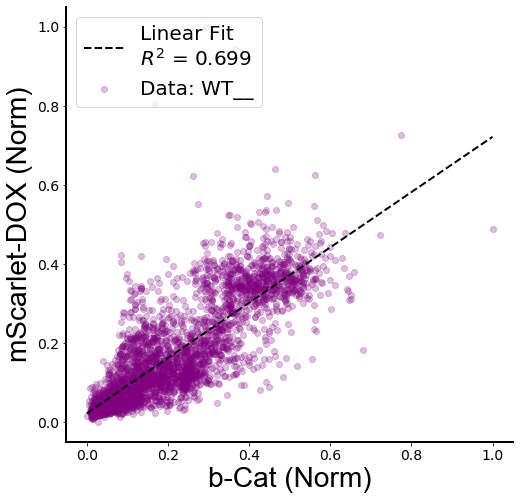

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.
The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.
The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


Processing group: Y654F__


The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.
The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.
The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.
The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.
The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.
The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.
The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.
The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.
The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.
The PostScript back

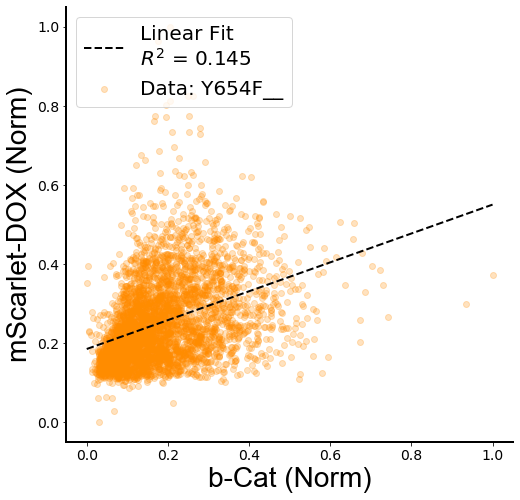

In [16]:
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
import numpy as np
import os

# --- CONFIGURATION: EDIT THESE FOR DIFFERENT EXPERIMENTS ---
label_ch1 = "b-Cat"
label_ch2 = "mScarlet-DOX"

# Map your dictionary keys to specific colors
# Note: Ensure these keys match your 'targets' list exactly
color_map = {
    'Y654F__': 'darkorange',
    'WT__':  'purple',
    'IWP2':    'navy',
    'CHIR':    'red',
    'Wnt3a':   'deeppink',
    'Parental': 'black'  # Added a default for Parental
}
# -----------------------------------------------------------

for exp_name, file_list in experiments.items():
    if not file_list:
        continue  
        
    print("Processing group: " + exp_name)
    
    # 1. Combine all CSVs for this specific key
    data_perexp = pd.DataFrame()
    for file in file_list:
        try:
            data = pd.read_csv(file)
            data_perexp = pd.concat([data_perexp, data], ignore_index=True)
        except Exception as e:
            print("Error reading %s: %s" % (file, e))

    if data_perexp.empty:
        continue

    # 2. Extract and Normalize Data
    x = data_perexp['mean channel 1'].astype(float)
    y = data_perexp['mean channel 2'].astype(float)
    
    x_norm = (x - x.min()) / (x.max() - x.min() + 1e-9)
    y_norm = (y - y.min()) / (y.max() - y.min() + 1e-9)
    
    mask = ~np.isnan(x_norm) & ~np.isnan(y_norm)
    x_final = x_norm[mask]
    y_final = y_norm[mask]

    # 3. Calculate Linear Regression
    slope, intercept, r_value, p_value, std_err = stats.linregress(x_final, y_final)
    r_squared = r_value**2

    # 4. Create Figure
    fig, ax = plt.subplots(figsize=(8, 8))

    # Lookup the color from our map, default to 'black' if key isn't found
    dot_color = color_map.get(exp_name, 'black')

    # Styling
    ax.spines['right'].set_visible(False)
    ax.spines['top'].set_visible(False)
    ax.spines['bottom'].set_linewidth(2)
    ax.spines['left'].set_linewidth(2)
    
    # Scatter plot using the specific color
    ax.scatter(x_final, y_final, marker='o', color=dot_color, 
               alpha=0.25, label="Data: " + exp_name)

    # Regression Line (kept black or grey for contrast against colored dots)
    line_x = np.array([0, 1]) # Since data is normalized 0-1
    line_y = slope * line_x + intercept
    ax.plot(line_x, line_y, color="black", linestyle="--", linewidth=2, 
            label="Linear Fit\n$R^2$ = %.3f" % r_squared)

    # Labels and Formatting
    #ax.set_title("Condition: " + exp_name, fontsize=18, fontname='Arial', fontweight='bold')
    ax.set_xlabel(label_ch1 + " (Norm)", fontsize=28, fontname='Arial')
    ax.set_ylabel(label_ch2 + " (Norm)", fontsize=28, fontname='Arial')
    
    # Force axes to 0-1 for normalized comparison
    ax.set_xlim(-0.05, 1.05)
    ax.set_ylim(-0.05, 1.05)
    
    plt.xticks(fontsize=14)
    plt.yticks(fontsize=14)
    ax.legend(loc='upper left', fontsize=20)

    # 5. Save
    # Dynamic filename based on the experiment key
    clean_name = exp_name.replace("+", "plus").replace("_", "")
    save_path = "C:/Users/nadia/Downloads/" + clean_name + "_plot.eps"
    
    # Uncomment to save automatically:
    fig.savefig(save_path, format='eps', transparent=True, bbox_inches='tight')
    
    plt.show()